# Car Price Prediction and Performance Analysis

This analysis develops and evaluates machine learning models to predict car prices based on performance characteristics. Using a comprehensive dataset of 1000+ vehicles from 2025, we implement regression models to understand the relationship between technical specifications and market pricing.

Dataset: Cars Datasets 2025 by Abdul Malik

Source: Kaggle (Public Repository)

URL: https://www.kaggle.com/datasets/abdulmalik1518/cars-datasets-2025/data

Licensed under the Apache License, Version 2.0 (the "License");
you may not use this file except in compliance with the License.
You may obtain a copy of the License at

    http://www.apache.org/licenses/LICENSE-2.0

Unless required by applicable law or agreed to in writing, software
distributed under the License is distributed on an "AS IS" BASIS,
WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.
See the License for the specific language governing permissions and
limitations under the License.

## Introduction

### Context

The global automotive market in 2025 is shaped by rapid electrification, tighter efficiency regulations, and increasingly diverse powertrain technologies. As a result, car pricing is no longer explained by engine size or brand alone; it reflects a combination of technical performance, fuel technology, and market positioning.

This study uses a structured vehicle dataset containing manufacturer details, power and speed metrics, acceleration performance, torque, fuel type, and listed prices. By examining these variables together, the analysis investigates how measurable engineering attributes relate to market value across economy, premium, and luxury segments.

Understanding these relationships is valuable for both consumers and industry stakeholders. Consumers benefit from clearer expectations of performance-to-price trade-offs, while analysts and manufacturers can use data-driven insights to benchmark pricing behavior and identify the strongest value drivers in modern vehicle markets.

### Research Objectives

- Identify and quantify the key technical and categorical factors that influence car prices across market segments.
- Explore distribution patterns, outliers, and relationships between performance metrics (e.g., horsepower, top speed, and acceleration) and vehicle prices.
- Develop and evaluate supervised machine learning models to predict car prices from performance characteristics and encoded categorical features.
- Compare model performance using MAE, RMSE, and R² metrics, and determine which modeling approach best captures non-linear pricing behavior.

## Data Exploration

In [1]:
# Importing libraries for data analysis
import pandas as  pd
import chardet
import re
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn import set_config

# Importing dataset csv file
with open("Cars Datasets 2025.csv", 'rb') as file:
    encoding = chardet.detect(file.read())['encoding']
data = pd.read_csv("Cars Datasets 2025.csv", encoding=encoding)

### Data Preprocessing

Goal -
1. Clean and standardise numerical data from mixed-format cells.
2. Ensuring consistency in text-based categorical variables by:
    - Removing leading/trailing whitespace
    - Converting to uppercase
    - Converting to title case
3. Encoded categorical data for analysis and machine learning models.

In [2]:
# Cleaning the data
def data_cleaning(a):
    if pd.isna(a): 
        return None
    a = str(a).replace(",", "").replace("$", "").strip()
    num = [float(x) for x in re.findall(r"\d+\.?\d*", a)]
    if not num:
        return None
    return sum(num)/len(num)

# Applying data cleaning to numerical columns
columns = ["CC/Battery Capacity", "HorsePower", "Total Speed", "Performance(0 - 100 )KM/H", "Cars Prices", "Torque"]
for column in columns:
    data[column] = data[column].apply(data_cleaning)

# Dropping seats column because it does not improve model performance
if "Seats" in data.columns:
    data.drop(columns=["Seats"], inplace=True)

# Cleaning text columns
data["Company Names"] = data["Company Names"].str.strip().str.upper()
data["Cars Names"] = data["Cars Names"].str.strip().str.title()
data["Engines"] = data["Engines"].str.strip().str.upper()

# Cleaning fuel types function
def clean_fuel_type(fuel):
    if pd.isna(fuel):
        return None
    
    fuel = str(fuel).strip().lower()
    
    # Replacing common variations and typos
    fuel = fuel.replace('plug in hyrbrid', 'plug-in hybrid')
    fuel = fuel.replace('plug-in hyrbrid', 'plug-in hybrid')
    fuel = fuel.replace('hyrbrid', 'hybrid')
    fuel = fuel.replace('petrol, hybrid', 'petrol/hybrid')
    fuel = fuel.replace('petrol/hybrid', 'petrol/hybrid')
    fuel = fuel.replace('petrol/diesel', 'petrol/diesel')
    fuel = fuel.replace('petrol/ev', 'petrol/electric')
    fuel = fuel.replace('hybrid (petrol)', 'hybrid')
    fuel = fuel.replace('hybrid (gas + electric)', 'hybrid')
    fuel = fuel.replace('petrol/awd', 'petrol')
    fuel = fuel.replace('cng/petrol', 'cng')
    fuel = fuel.replace('petrol, hybrid', 'petrol/hybrid')
    fuel = fuel.replace('hybrid/electric', 'hybrid')
    fuel = fuel.replace('petrol/hydrogen', 'hydrogen')
    if '/' in fuel:
        parts = fuel.split('/')
        fuel_parts = [part for part in parts if part in ['petrol', 'diesel', 'electric', 'hybrid', 'hydrogen', 'cng']]
        if fuel_parts:
            fuel_parts.sort()
            fuel = '/'.join(fuel_parts)
        else:
            fuel = parts[0]
    
    # Standardizing common fuel types
    fuel_mapping = {'petrol': 'petrol', 'gasoline': 'petrol', 'diesel': 'diesel',
                    'electric': 'electric', 'hybrid': 'hybrid', 'plug-in hybrid': 'plug-in hybrid',
                    'hydrogen': 'hydrogen', 'cng': 'cng', 'petrol/hybrid': 'hybrid/petrol',
                    'diesel/petrol': 'diesel/petrol', 'petrol/diesel': 'diesel/petrol', 'petrol/electric': 'petrol/electric'}
    
    # Returning mapped value if exact match, otherwise return cleaned original
    return fuel_mapping.get(fuel, fuel)

# Applying fuel type cleaning
data["Fuel Types"] = data["Fuel Types"].apply(clean_fuel_type)

In [3]:
# Encoding Categorical data
categorical_cols = ['Company Names', 'Fuel Types', 'Engines']
label_encoders = {}

for col in categorical_cols:
    le = LabelEncoder()
    data[f'{col}_encoded'] = le.fit_transform(data[col])
    label_encoders[col] = le
    
    # Print mappings
    print(f"{col} = Number Mapping:")
    for i, category in enumerate(le.classes_):
        print(f"{category} = {i}")
    print("-" * 50)

Company Names = Number Mapping:
ACURA = 0
ASTON MARTIN = 1
AUDI = 2
BENTLEY = 3
BMW = 4
BUGATTI = 5
CADILLAC = 6
CHEVROLET = 7
FERRARI = 8
FORD = 9
GMC = 10
HONDA = 11
HYUNDAI = 12
JAGUAR LAND ROVER = 13
JEEP = 14
KIA = 15
LAMBORGHINI = 16
MAHINDRA = 17
MARUTI SUZUKI = 18
MAZDA = 19
MERCEDES = 20
MITSUBISHI = 21
NISSAN = 22
PEUGEOT = 23
PORSCHE = 24
ROLLS ROYCE = 25
TATA MOTORS = 26
TESLA = 27
TOYOTA = 28
VOLKSWAGEN = 29
VOLVO = 30
--------------------------------------------------
Fuel Types = Number Mapping:
cng = 0
diesel = 1
diesel hybrid = 2
diesel/petrol = 3
electric = 4
electric/petrol = 5
gas  = 6
hybrid = 7
hybrid  = 8
hybrid/petrol = 9
hydrogen = 10
petrol = 11
petrol (hybrid) = 12
petrol, diesel = 13
plug-in hybrid = 14
--------------------------------------------------
Engines = Number Mapping:
0.36L INLINE-2 = 0
0.66L INLINE-3 = 1
0.7L 3-CYLINDER = 2
1.0L ECOBOOST / 1.5L = 3
1.0L ECOBOOST / 1.5L / 2.0L = 4
1.0L I3 TURBO = 5
1.0L I3 TURBO / 1.5L I4 TURBO = 6
1.0L INLINE-2 (

### Data Inspection

In [4]:
# Displaying first 5 rows of the dataset
data.head()

,Company Names,Cars Names,Engines,CC/Battery Capacity,HorsePower,Total Speed,Performance(0 - 100 )KM/H,Cars Prices,Fuel Types,Torque,Company Names_encoded,Fuel Types_encoded,Engines_encoded
0,FERRARI,Sf90 Stradale,V8,3990.0,963.0,340.0,2.5,1100000.0,plug-in hybrid,800.0,8,14,350
1,ROLLS ROYCE,Phantom,V12,6749.0,563.0,250.0,5.3,460000.0,petrol,900.0,25,11,342
2,FORD,Ka+,1.2L PETROL,1200.0,77.5,165.0,10.5,13500.0,petrol,120.0,9,11,26
3,MERCEDES,Gt 63 S,V8,3982.0,630.0,250.0,3.2,161000.0,petrol,900.0,20,11,350
4,AUDI,Audi R8 Gt,V10,5204.0,602.0,320.0,3.6,253290.0,petrol,560.0,2,11,341


In [5]:
# Displaying the last 5 rows of the dataset
data.tail()

,Company Names,Cars Names,Engines,CC/Battery Capacity,HorsePower,Total Speed,Performance(0 - 100 )KM/H,Cars Prices,Fuel Types,Torque,Company Names_encoded,Fuel Types_encoded,Engines_encoded
1213,TOYOTA,Crown Signia,2.5L HYBRID I4,2487.0,240.0,180.0,7.60,45795.0,hybrid,239.0,28,7,173
1214,TOYOTA,4Runner (6Th Gen),2.4L TURBO I4 (I-FORCE MAX HYBRID),2393.0,326.0,180.0,6.80,50000.0,hybrid,630.0,28,7,168
1215,TOYOTA,Corolla Cross,2.0L GAS / 2.0L HYBRID,1987.0,182.5,190.0,8.60,27172.5,gas,200.0,28,6,120
1216,TOYOTA,C-Hr+,1.8L / 2.0L HYBRID,1892.5,169.0,180.0,9.20,33000.0,hybrid,197.5,28,7,106
1217,TOYOTA,Rav4 (6Th Gen),2.5L HYBRID / PLUG-IN HYBRID,2487.0,260.5,200.0,7.05,36000.0,hybrid,310.5,28,8,172


In [6]:
# Displaying the shape of the dataset (Rows, Columns)
data.shape

(1218, 13)

In [7]:
# Displaying the data
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1218 entries, 0 to 1217
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Company Names              1218 non-null   object 
 1   Cars Names                 1218 non-null   object 
 2   Engines                    1218 non-null   object 
 3   CC/Battery Capacity        1213 non-null   float64
 4   HorsePower                 1218 non-null   float64
 5   Total Speed                1218 non-null   float64
 6   Performance(0 - 100 )KM/H  1212 non-null   float64
 7   Cars Prices                1217 non-null   float64
 8   Fuel Types                 1218 non-null   object 
 9   Torque                     1217 non-null   float64
 10  Company Names_encoded      1218 non-null   int64  
 11  Fuel Types_encoded         1218 non-null   int64  
 12  Engines_encoded            1218 non-null   int64  
dtypes: float64(6), int64(3), object(4)
memory usage:

In [8]:
# Describing the dataset
data.describe()

,CC/Battery Capacity,HorsePower,Total Speed,Performance(0 - 100 )KM/H,Cars Prices,Torque,Company Names_encoded,Fuel Types_encoded,Engines_encoded
count,1213.000000,1218.000000,1218.000000,1212.000000,1.217000e+03,1217.000000,1218.000000,1218.000000,1218.000000
mean,2703.311689,307.422824,216.467159,7.564686,1.380370e+05,506.892358,17.823481,9.120690,222.897373
std,1942.861991,222.722922,53.051077,3.312010,7.110424e+05,1049.512321,8.182946,3.404919,101.241319
min,1.240000,26.000000,80.000000,1.900000,4.000000e+03,45.000000,0.000000,0.000000,0.000000
25%,1500.000000,153.250000,180.000000,5.275000,2.800000e+04,250.000000,10.000000,7.000000,130.000000
50%,2000.000000,255.000000,200.000000,7.100000,4.250000e+04,370.000000,20.500000,11.000000,252.000000
75%,3500.000000,400.000000,250.000000,9.500000,7.000000e+04,560.000000,24.000000,11.000000,309.000000
max,16100.000000,2488.000000,500.000000,35.000000,1.800000e+07,15590.000000,30.000000,14.000000,352.000000


In [9]:
# Displaying the data types
data.dtypes

Company Names                 object
Cars Names                    object
Engines                       object
CC/Battery Capacity          float64
HorsePower                   float64
Total Speed                  float64
Performance(0 - 100 )KM/H    float64
Cars Prices                  float64
Fuel Types                    object
Torque                       float64
Company Names_encoded          int64
Fuel Types_encoded             int64
Engines_encoded                int64
dtype: object

In [10]:
# Displaying the number of duplicate rows
data.duplicated().sum()

np.int64(5)

In [11]:
# Displaying the duplicate rows if found
data[data.duplicated(keep=False)]

,Company Names,Cars Names,Engines,CC/Battery Capacity,HorsePower,Total Speed,Performance(0 - 100 )KM/H,Cars Prices,Fuel Types,Torque,Company Names_encoded,Fuel Types_encoded,Engines_encoded
2,FORD,Ka+,1.2L PETROL,1200.0,77.5,165.0,10.5,13500.0,petrol,120.0,9,11,26
314,VOLKSWAGEN,Golf Cabriolet,1.2L I4 TURBO / 2.0L I4 TURBO,1590.5,157.5,217.0,8.4,30000.0,petrol,200.0,29,11,20
336,VOLKSWAGEN,Golf Cabriolet,1.2L I4 TURBO / 2.0L I4 TURBO,1590.5,157.5,217.0,8.4,30000.0,petrol,200.0,29,11,20
348,VOLKSWAGEN,Jetta Hybrid,1.4L I4 TURBO + ELECTRIC MOTOR,1395.0,170.0,210.0,8.6,28000.0,hybrid,250.0,29,7,56
354,VOLKSWAGEN,Jetta Hybrid,1.4L I4 TURBO + ELECTRIC MOTOR,1395.0,170.0,210.0,8.6,28000.0,hybrid,250.0,29,7,56
629,TATA MOTORS,Tiago Ev,PERMANENT MAGNET SYNCHRONOUS,24.0,74.0,120.0,5.7,11000.0,electric,114.0,26,4,324
658,TATA MOTORS,Tiago Ev,PERMANENT MAGNET SYNCHRONOUS,24.0,74.0,120.0,5.7,11000.0,electric,114.0,26,4,324
750,CHEVROLET,Tahoe Rst,5.3L V8 GASOLINE,5300.0,355.0,180.0,7.4,64100.0,petrol,519.0,7,11,271
755,CHEVROLET,Tahoe Rst,5.3L V8 GASOLINE,5300.0,355.0,180.0,7.4,64100.0,petrol,519.0,7,11,271
1018,FORD,Ka+,1.2L PETROL,1200.0,77.5,165.0,10.5,13500.0,petrol,120.0,9,11,26


In [12]:
# Handling duplicate data by dropping the rows with duplicate values if found
data.drop_duplicates(inplace=True)
data.duplicated().sum()

np.int64(0)

In [13]:
# Displaying the number of missing values
data.isnull().sum()

Company Names                0
Cars Names                   0
Engines                      0
CC/Battery Capacity          5
HorsePower                   0
Total Speed                  0
Performance(0 - 100 )KM/H    6
Cars Prices                  1
Fuel Types                   0
Torque                       1
Company Names_encoded        0
Fuel Types_encoded           0
Engines_encoded              0
dtype: int64

In [14]:
# Displaying the rows with missing values if found
data[data.isnull().any(axis=1)]

,Company Names,Cars Names,Engines,CC/Battery Capacity,HorsePower,Total Speed,Performance(0 - 100 )KM/H,Cars Prices,Fuel Types,Torque,Company Names_encoded,Fuel Types_encoded,Engines_encoded
97,MERCEDES,Benz Eqs 53,ELECTRIC MOTOR,NaN,751.0,250.0,3.4,102000.0,electric,950.0,20,4,300
241,TOYOTA,Coaster,"4.0L,DIESEL",4009.0,134.0,120.0,NaN,70000.0,diesel,500.0,28,1,260
255,NISSAN,Urvan,2.5L TURBO DIESE,NaN,2488.0,140.0,14.0,28000.0,diesel,356.0,22,1,182
994,PEUGEOT,Partner Electric,ELECTRIC MOTOR,NaN,136.0,130.0,9.0,40000.0,electric,260.0,23,4,300
995,PEUGEOT,Expert Electric,ELECTRIC MOTOR,NaN,136.0,130.0,9.5,45000.0,electric,260.0,23,4,300
1096,MITSUBISHI,Canter (Truck),3.0L DIESEL,3000.0,150.0,120.0,NaN,40000.0,diesel,370.0,21,1,208
1107,MITSUBISHI,Fuso Fighter (Truck),7.5L DIESEL,7500.0,240.0,120.0,NaN,80000.0,diesel,686.0,21,1,288
1108,MITSUBISHI,Fuso Canter Eco Hybrid,3.0L DIESEL HYBRID,3000.0,150.0,120.0,NaN,55000.0,diesel hybrid,370.0,21,2,209
1126,MITSUBISHI,Minicab Miev,ELECTRIC MOTOR,16.0,64.0,100.0,NaN,19000.0,electric,196.0,21,4,300
1147,MAZDA,Rx-Vision Concept,ROTARY SKYACTIV-R,NaN,400.0,300.0,NaN,NaN,petrol (hybrid),NaN,19,12,330


In [15]:
# Handling missing data by dropping the rows with missing values if found
data.dropna(inplace=True)
data.isnull().sum()

Company Names                0
Cars Names                   0
Engines                      0
CC/Battery Capacity          0
HorsePower                   0
Total Speed                  0
Performance(0 - 100 )KM/H    0
Cars Prices                  0
Fuel Types                   0
Torque                       0
Company Names_encoded        0
Fuel Types_encoded           0
Engines_encoded              0
dtype: int64

In [16]:
# Displaying HorsePower descriptive statistics
data.HorsePower.describe()

count    1203.000000
mean      306.698254
std       214.017560
min        26.000000
25%       155.000000
50%       255.000000
75%       400.000000
max      1850.000000
Name: HorsePower, dtype: float64

## Exploratory Data Analysis (EDA)

### Distribution of Car Prices on Log Scale

The distribution shows a highly right-skewed pattern with extreme positive skewness (16.49) and very high kurtosis (351.85), indicating significant outliers in the upper price range. Most vehicles cluster in the lower-to-mid price range of approximately USD 4,000 to USD 500,000, with frequency declining sharply as prices increase. The substantial difference between the mean USD 139,439.82 and median USD 42,500.00 confirms that luxury and hypercar segments significantly inflate the average price whilst most vehicles remain affordable to mid-range.

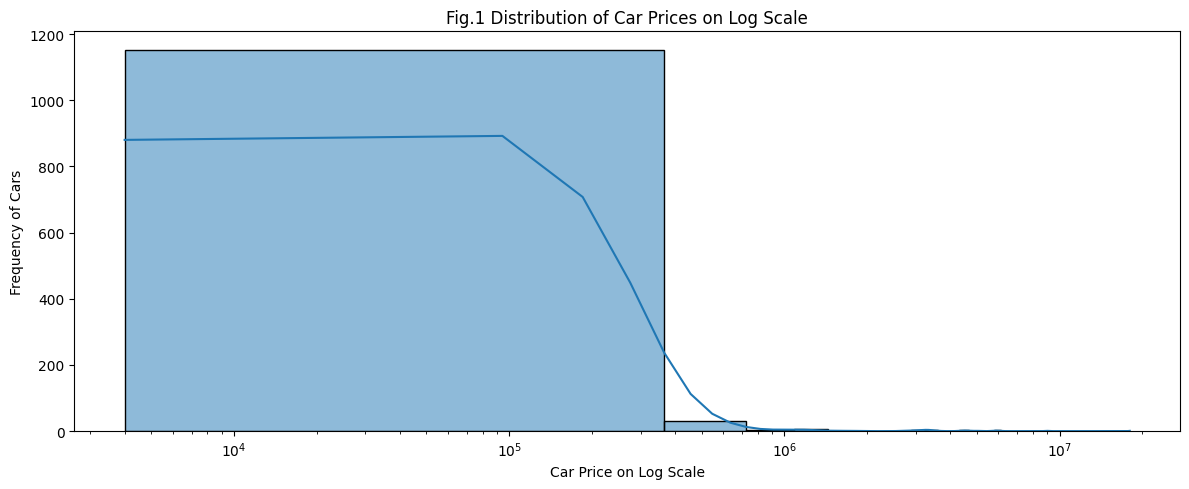

Car Prices Statistics:
Skewness: 16.57
Kurtosis: 355.32
Min Price: $4,000.00
Max Price: $18,000,000.00
Mean Price: $139,123.33
Median Price: $42,795.00


In [34]:
# Displaying the distribution of Car Prices on Log Scale
plt.figure(figsize=(12,5))
sns.histplot(data['Cars Prices'], kde=True, bins=50)
plt.xscale('log')
plt.title('Fig.1 Distribution of Car Prices on Log Scale')
plt.xlabel('Car Price on Log Scale')
plt.ylabel('Frequency of Cars')
plt.tight_layout()
plt.show()

# Statistics for Car Prices
print("Car Prices Statistics:")
print(f"Skewness: {data['Cars Prices'].skew():.2f}")
print(f"Kurtosis: {data['Cars Prices'].kurt():.2f}")
print(f"Min Price: ${data['Cars Prices'].min():,.2f}")
print(f"Max Price: ${data['Cars Prices'].max():,.2f}")
print(f"Mean Price: ${data['Cars Prices'].mean():,.2f}")
print(f"Median Price: ${data['Cars Prices'].median():,.2f}")

### Distribution of Car Prices by Fuel Types

The barplot displays average car prices across different fuel types, revealing clear pricing hierarchies in the automotive market. Petrol/Hybrid and Gas fuel types command the highest average prices, reflecting their prevalence in premium and luxury vehicle segments. Hydrogen fuel technology shows elevated average pricing, indicating its current association with high-end applications. Diesel/Petrol combinations occupy the mid-range tier with moderate average prices. Electric and CNG vehicles demonstrate the lowest average prices, confirming their positioning as accessible and economical powertrain options. These distinct price tiers suggest that fuel technology choice remains strongly correlated with vehicle market segment and brand positioning.

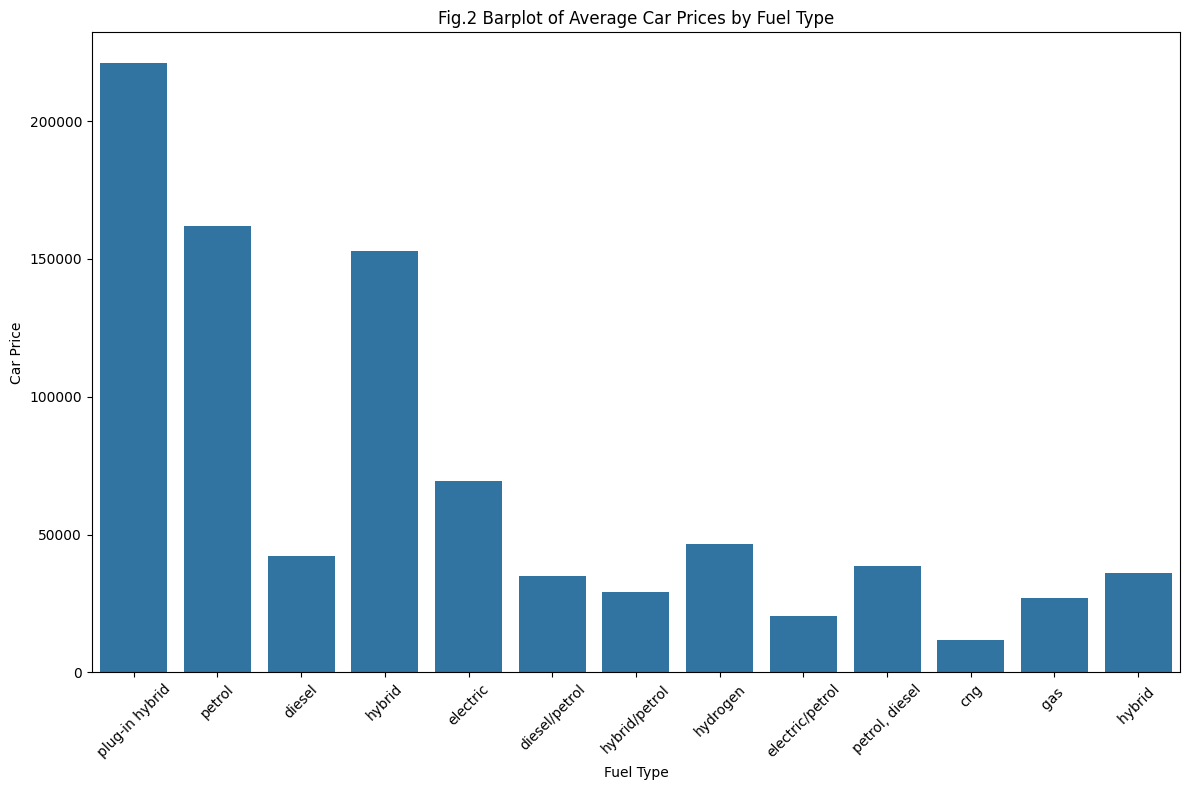

In [ ]:
# Displaying the Barplot of Average Car Prices by Fuel Type
plt.figure(figsize=(12, 8))
fuel_type_mapping = {i: fuel for i, fuel in enumerate(label_encoders['Fuel Types'].classes_)}
data['Fuel Type'] = data['Fuel Types_encoded'].map(fuel_type_mapping)
sns.barplot(x='Fuel Type', y='Cars Prices', data=data, errorbar=None)
plt.title("Fig.2 Barplot of Average Car Prices by Fuel Type")
plt.xlabel("Fuel Type")
plt.ylabel("Car Price")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Distribution of Car Prices by Company Names

The boxplot reveals substantial inter-brand pricing disparities. Bugatti demonstrates the highest median prices with extreme outliers extending to USD 18,000,000, while Ferrari, Lamborghini, and Rolls-Royce maintain consistently elevated price ranges. Mass-market manufacturers such as Suzuki, Honda, and Toyota cluster in lower price ranges of USD 10,000 to USD 50,000 with minimal outliers, suggesting consistent positioning within affordable segments. BMW, Mercedes, and Audi occupy intermediate positions with moderate ranges and some performance variant outliers.

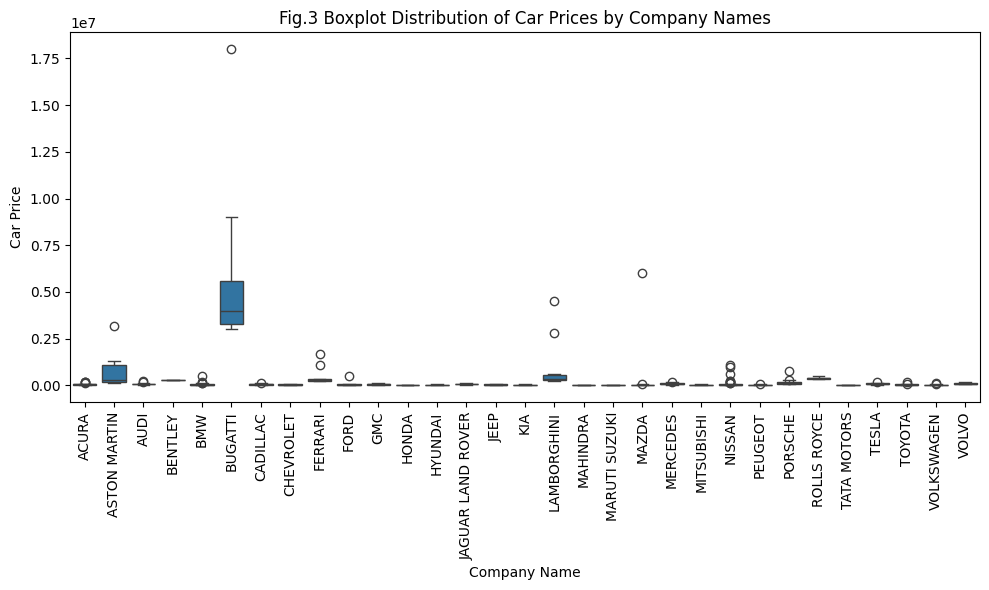

In [19]:
# Displaying the boxplot distribution of Car Prices and Company Names
plt.figure(figsize=(10, 6))
le = LabelEncoder()
data['Company Names_encoded'] = le.fit_transform(data['Company Names'])
company_name_mapping = {i: company for i, company in enumerate(le.classes_)}
sns.boxplot(data=data, x='Company Names_encoded', y='Cars Prices')
tick_locations = plt.gca().get_xticks()
tick_labels = [company_name_mapping.get(tick, '') for tick in tick_locations]
plt.xticks(ticks=tick_locations, labels=tick_labels, rotation=90)
plt.title('Fig.3 Boxplot Distribution of Car Prices by Company Names')
plt.xlabel('Company Name')
plt.ylabel('Car Price')
plt.tight_layout()
plt.show()

### Correlation between HorsePower and Car Prices -

The scatterplot demonstrates a moderate positive correlation (0.53) between HorsePower and vehicle pricing, representing the strongest relationship among technical specifications. Clear clustering patterns emerge: economy vehicles with 100-200 HP priced under USD 50,000, mid-range vehicles with 200-400 HP showing increasing price variance from USD 50,000 to USD 200,000, and high-performance vehicles with 400+ HP exhibiting exponential price growth. Extreme outliers with 1000+ HP reaching prices above USD 1,000,000 represent hypercars and limited editions. This correlation confirms that power output is a key pricing determinant, though substantial variance indicates brand positioning and luxury features also significantly influence pricing.

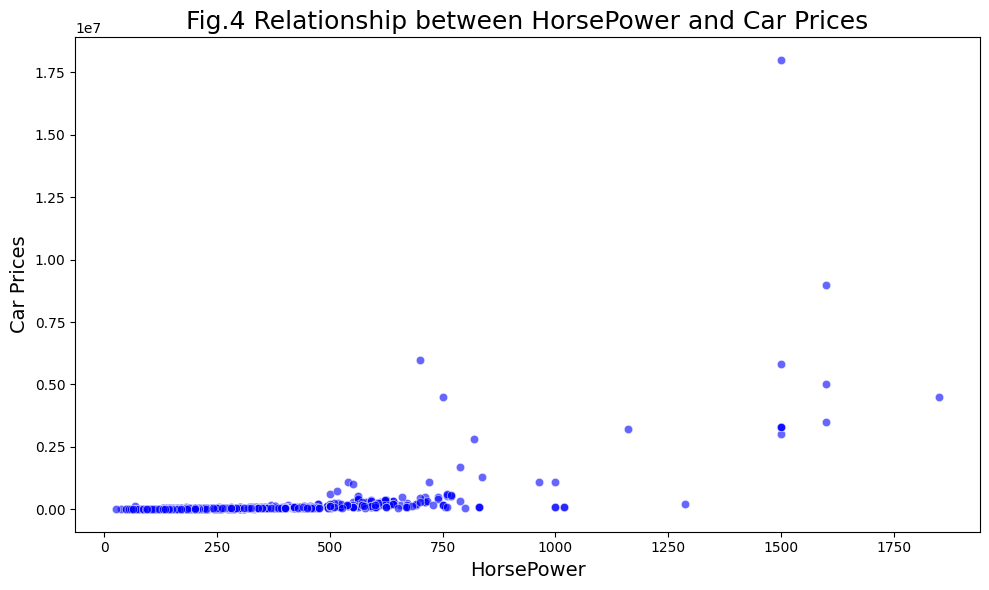

In [20]:
# Displaying the correlation between Cars Prices and HorsePower using the scatterplot
plt.figure(figsize=(10,6))
sns.scatterplot(x='HorsePower', y='Cars Prices', color='b', data=data, alpha=0.6)
plt.title('Fig.4 Relationship between HorsePower and Car Prices', size=18)
plt.xlabel('HorsePower', size=14)
plt.ylabel('Car Prices', size=14)
plt.tight_layout()
plt.show()

### Correlation Matrix

The correlation matrix reveals that HorsePower shows the strongest relationship with Total Speed (0.75) and Cars Prices (0.53), whilst Performance (0-100 KM/H) demonstrates strong negative correlations with Total Speed (-0.79) and HorsePower (-0.68), as faster acceleration correlates with higher power and speed. The relatively modest correlations between technical specifications and price (0.28-0.53 range) suggest that brand prestige and market positioning substantially influence pricing beyond raw performance metrics.

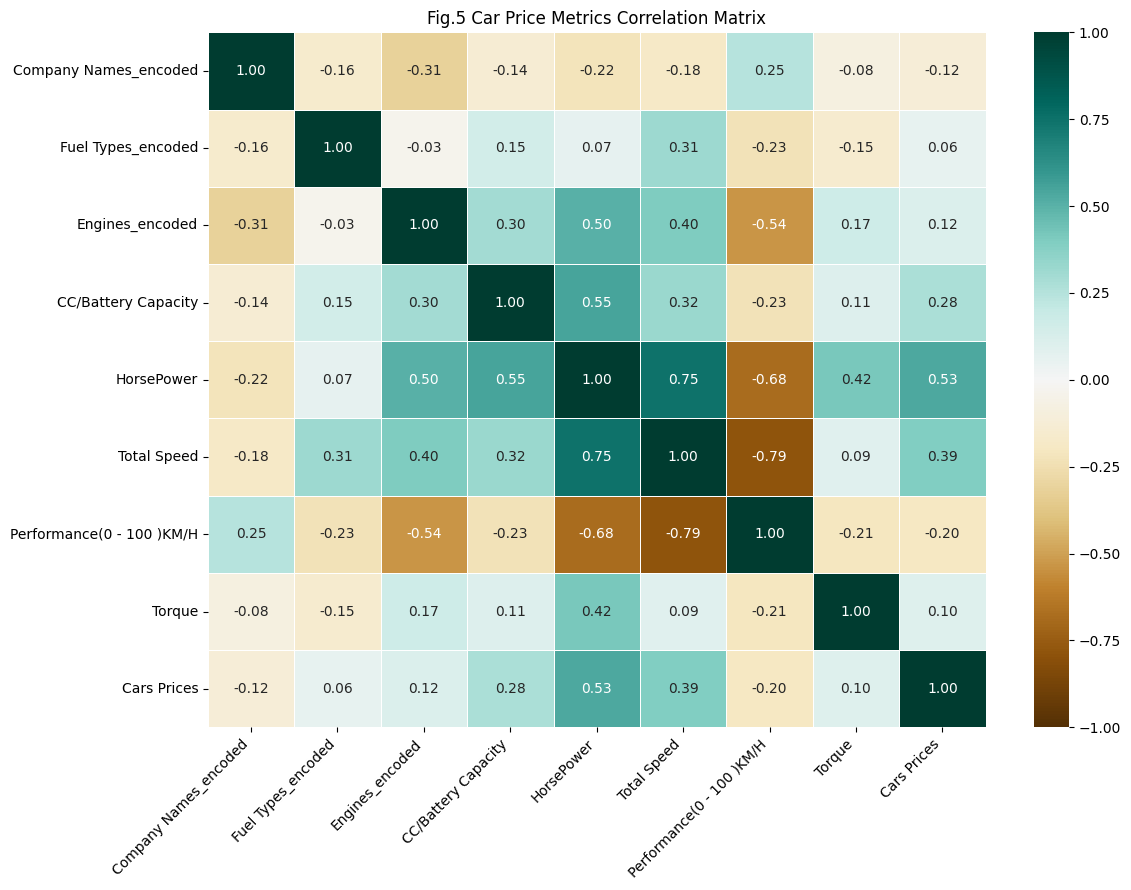

In [21]:
# Displaying the of Company Names, Fuel Types, Engines, CC/Battery Capacity, HorsePower, Total Speed, Performance(0 - 100 )KM/H, Torque and Cars Prices correlation
factors = ['Company Names_encoded', 'Fuel Types_encoded', 'Engines_encoded', 'CC/Battery Capacity', 'HorsePower', 'Total Speed',
           'Performance(0 - 100 )KM/H', 'Torque', 'Cars Prices']
data_clean = data[factors].copy()
corrmat = data_clean.corr()
f, ax = plt.subplots(figsize=(12, 9))
sns.heatmap(corrmat, vmin=-1, vmax=1, annot=True, cmap='BrBG', center=0, fmt='.2f', linewidths=0.5)
plt.title('Fig.5 Car Price Metrics Correlation Matrix')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

### Distribution of HorsePower and the Frequency of Cars

The distribution exhibits a strong right-skew with most vehicles clustered in the 100-400 horsepower range, peaking around 200-250 HP. The long tail extending towards 2000+ HP represents high-performance sports cars and hypercars, though these constitute a small proportion of the dataset. This pattern aligns with market expectations where economical and mid-range vehicles dominate sales volume whilst extreme performance variants remain niche products.

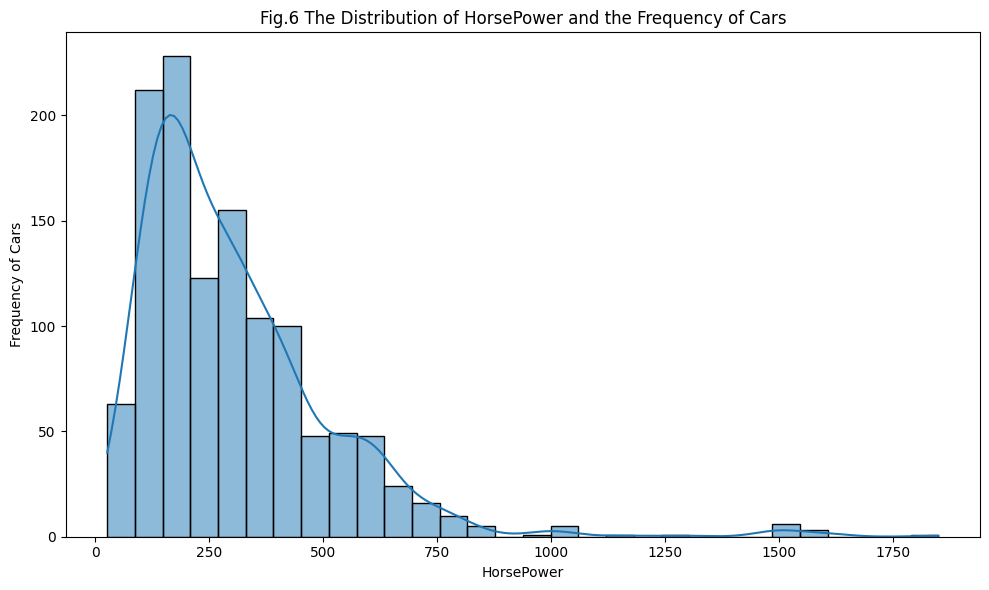

Skewness: 2.35
Kurtosis: 9.73


In [22]:
# Displaying HorsePower and the count of cars distribution
plt.figure(figsize=(10,6))
sns.histplot(data['HorsePower'], kde=True, bins=30)
plt.title('Fig.6 The Distribution of HorsePower and the Frequency of Cars')
plt.xlabel('HorsePower')
plt.ylabel('Frequency of Cars')
plt.tight_layout()
plt.show()
# Measure of distortion of symmetric distribution
print(f"Skewness: {data['HorsePower'].skew():.2f}")
print(f"Kurtosis: {data['HorsePower'].kurt():.2f}")

## Machine Learning Analysis

### Machine Learning Pipeline

The machine learning pipeline provides several key advantages: it ensures reproducibility by encapsulating preprocessing and modeling steps in a single object, maintains consistency between training and test data transformations, simplifies model deployment procedures, prevents data leakage by fitting transformers only on training data, and enables efficient experimentation with different preprocessing strategies. The Pipeline structure integrates StandardScaler for feature scaling and combines numeric and categorical feature processing through ColumnTransformer, creating a robust and maintainable framework for car price prediction.

In [23]:
# Defining a pipeline for data preprocessing and modeling
def create_car_price_pipeline():
    print("Starting Car Price Prediction Pipeline")
    
    # Create a copy of the dataframe to avoid side effects
    df = data.copy()
    
    # Define feature types
    numeric_features = ['CC/Battery Capacity', 'HorsePower', 'Total Speed', 
                        'Performance(0 - 100 )KM/H', 'Torque']
    categorical_features = ['Company Names_encoded', 'Fuel Types_encoded', 'Engines_encoded']
    target_feature = 'Cars Prices'
    
    # Combine all features
    features = numeric_features + categorical_features
    
    # Separate features and target variable
    X = df[features].copy()
    y = df[target_feature].copy()
    
    # Preprocessing for numeric features
    numeric_transformer = Pipeline(
        steps=[('scaler', StandardScaler())]
    )
    
    # Preprocessing for categorical features (already encoded, so just scale)
    categorical_transformer = Pipeline(
        steps=[('scaler', StandardScaler())]
    )
    
    # Combine preprocessing using ColumnTransformer
    preprocessor = ColumnTransformer(
        transformers=[
            ('numerical', numeric_transformer, numeric_features),
            ('categorical', categorical_transformer, categorical_features)
        ]
    )
    
    print("Preprocessing pipeline created")
    
    # Split data into train and test sets
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=324)
    
    # Create Linear Regression pipeline with preprocessing and modeling
    lr_pipeline = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("lr_regressor", LinearRegression())
        ]
    )
    
    # Create Random Forest Regressor pipeline with preprocessing and modeling
    rf_pipeline = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("rf_regressor", RandomForestRegressor(
                n_estimators=100,
                random_state=324,
                n_jobs=-1
            ))
        ]
    )
    
    # Train Linear Regression model and make predictions
    print("Training Linear Regression model")
    lr_pipeline.fit(X_train, y_train)
    lr_predictions = lr_pipeline.predict(X_test)
    
    # Calculate Linear Regression metrics
    lr_mae = mean_absolute_error(y_test, lr_predictions)
    lr_rmse = np.sqrt(mean_squared_error(y_test, lr_predictions))
    lr_r2 = r2_score(y_test, lr_predictions)
    
    # Train Random Forest model and make predictions
    print("Training Random Forest model")
    rf_pipeline.fit(X_train, y_train)
    rf_predictions = rf_pipeline.predict(X_test)
    
    # Calculate Random Forest metrics
    rf_mae = mean_absolute_error(y_test, rf_predictions)
    rf_rmse = np.sqrt(mean_squared_error(y_test, rf_predictions))
    rf_r2 = r2_score(y_test, rf_predictions)
    
    print("Model training complete")
    print("Pipeline created successfully")
    
    return {
        "df": df,
        "features": features,
        "X_train": X_train,
        "X_test": X_test,
        "y_train": y_train,
        "y_test": y_test,
        "lr_pipeline": lr_pipeline,
        "lr_predictions": lr_predictions,
        "lr_mae": lr_mae,
        "lr_rmse": lr_rmse,
        "lr_r2": lr_r2,
        "rf_pipeline": rf_pipeline,
        "rf_predictions": rf_predictions,
        "rf_mae": rf_mae,
        "rf_rmse": rf_rmse,
        "rf_r2": rf_r2
    }

In [24]:
# Run pipeline
pipeline_result = create_car_price_pipeline()

# Extract results
df = pipeline_result['df']
features = pipeline_result['features']
X_train = pipeline_result['X_train']
X_test = pipeline_result['X_test']
y_train = pipeline_result['y_train']
y_test = pipeline_result['y_test']
lr_pipeline = pipeline_result['lr_pipeline']
lr_predictions = pipeline_result['lr_predictions']
lr_mae = pipeline_result['lr_mae']
lr_rmse = pipeline_result['lr_rmse']
lr_r2 = pipeline_result['lr_r2']
rf_pipeline = pipeline_result['rf_pipeline']
rf_predictions = pipeline_result['rf_predictions']
rf_mae = pipeline_result['rf_mae']
rf_rmse = pipeline_result['rf_rmse']
rf_r2 = pipeline_result['rf_r2']

Starting Car Price Prediction Pipeline
Preprocessing pipeline created
Training Linear Regression model
Training Random Forest model
Model training complete
Pipeline created successfully


In [25]:
# Display the Random Forest pipeline structure as a diagram
set_config(display='diagram')
print("Random Forest Pipeline Structure:")
rf_pipeline

Random Forest Pipeline Structure:


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('rf_regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numerical', ...), ('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the diff

In [26]:
# Display the Linear Regression pipeline structure as a diagram
set_config(display='diagram')
print("Linear Regression Pipeline Structure:")
lr_pipeline

Linear Regression Pipeline Structure:


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('lr_regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numerical', ...), ('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the diff

In [27]:
# Compare the performance of both models from pipeline
pipeline_results_df = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest Regression'],
    'MAE': [lr_mae, rf_mae],
    'RMSE': [lr_rmse, rf_rmse],
    'R² Score': [lr_r2, rf_r2]
})
pipeline_results_df['MAE'] = pipeline_results_df['MAE'].apply(lambda x: f"${x:,.2f}")
pipeline_results_df['RMSE'] = pipeline_results_df['RMSE'].apply(lambda x: f"${x:,.2f}")
pipeline_results_df['R² Score'] = pipeline_results_df['R² Score'].apply(lambda x: f"{x:.2f}")
print("\nPipeline Model Comparison:")
print(pipeline_results_df.to_string(index=False))

# Determining best model
if rf_r2 > lr_r2:
    best_model = 'Random Forest Regression'
    print(f"\nBest performing model: {best_model}")
elif rf_r2 < lr_r2:
    best_model = 'Linear Regression'
    print(f"\nBest performing model: {best_model}")
else:
    print("\nBoth models have the same R² Score. No clear best model.")


Pipeline Model Comparison:
                   Model         MAE        RMSE R² Score
       Linear Regression $196,655.68 $432,700.90     0.51
Random Forest Regression  $43,335.41 $293,773.92     0.77

Best performing model: Random Forest Regression


Random Forest Regression remains the superior model, reducing MAE from USD 196,655.68 to USD 43,335.41 (about 78% lower) and improving R² from 0.51 to 0.77. This stronger performance reflects its ability to capture non-linear relationships and feature interactions that linear models miss. Despite this improvement, the RMSE of USD 293,773.92 indicates that errors are still substantial for high-end and extreme luxury vehicles, where market positioning and brand prestige likely drive prices beyond technical specifications alone.

### Model Performance Visualizations

#### Actual vs Predicted Prices

The actual vs predicted scatter plots show clear improvement in Random Forest performance over Linear Regression. The Random Forest model (Fig.7b) clusters more tightly around the ideal prediction line and achieves the higher R² score of 0.77, while Linear Regression (Fig.7a) attains R² = 0.51 with visibly wider dispersion. Both models still show larger prediction spread for very high-priced vehicles, but Random Forest tracks non-linear pricing behavior more effectively across most of the dataset.

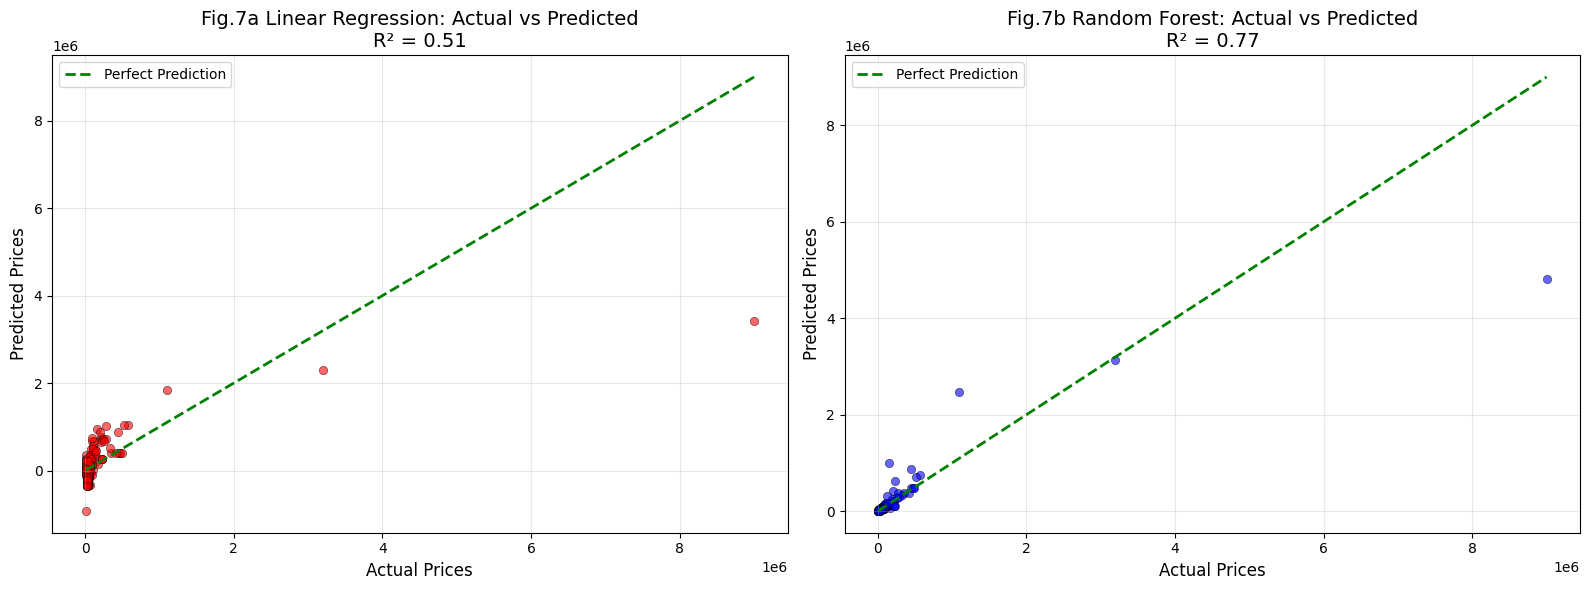

In [28]:
# Actual vs Predicted Prices - Comparison of Both Models
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Linear Regression - Actual vs Predicted
axes[0].scatter(y_test, lr_predictions, alpha=0.6, color='red', edgecolors='k', linewidth=0.5)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'g--', lw=2, label='Perfect Prediction')
axes[0].set_xlabel('Actual Prices', fontsize=12)
axes[0].set_ylabel('Predicted Prices', fontsize=12)
axes[0].set_title(f'Fig.7a Linear Regression: Actual vs Predicted\nR² = {lr_r2:.2f}', fontsize=14)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Random Forest - Actual vs Predicted
axes[1].scatter(y_test, rf_predictions, alpha=0.6, color='blue', edgecolors='k', linewidth=0.5)
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'g--', lw=2, label='Perfect Prediction')
axes[1].set_xlabel('Actual Prices', fontsize=12)
axes[1].set_ylabel('Predicted Prices', fontsize=12)
axes[1].set_title(f'Fig.7b Random Forest: Actual vs Predicted\nR² = {rf_r2:.2f}', fontsize=14)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

#### Residual Plots

Residual plots expose systematic prediction errors in both models. Linear Regression (Fig.8a) exhibits a pronounced funnel pattern with residuals spreading wider at higher predicted values, violating homoscedasticity assumptions and indicating the model systematically underestimates high-value vehicles. The pattern reveals that linear assumptions fail for automotive pricing. Random Forest (Fig.8b) demonstrates improved residual distribution with more random scatter around zero, though still showing increased variance at higher price predictions. The RMSE reduction from Linear Regression to Random Forest confirms superior error management. However, extreme positive and negative residuals in both models, particularly above USD 500,000 predictions, indicate that luxury segment pricing remains challenging due to factors beyond captured technical specifications.

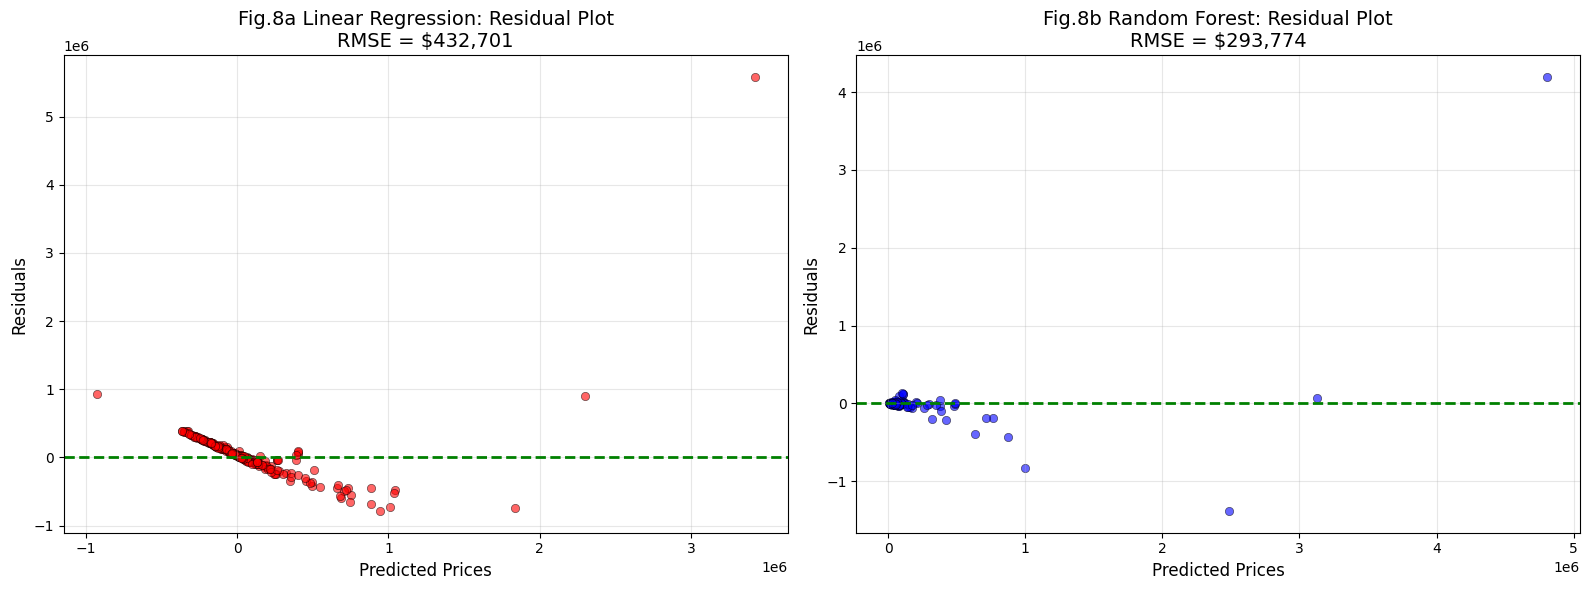

In [29]:
# Residual Plots - Comparison of Both Models
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Linear Regression Residuals
lr_residuals = y_test - lr_predictions
axes[0].scatter(lr_predictions, lr_residuals, alpha=0.6, color='red', edgecolors='k', linewidth=0.5)
axes[0].axhline(y=0, color='g', linestyle='--', lw=2)
axes[0].set_xlabel('Predicted Prices', fontsize=12)
axes[0].set_ylabel('Residuals', fontsize=12)
axes[0].set_title(f'Fig.8a Linear Regression: Residual Plot\nRMSE = ${lr_rmse:,.0f}', fontsize=14)
axes[0].grid(True, alpha=0.3)

# Random Forest Residuals
rf_residuals = y_test - rf_predictions
axes[1].scatter(rf_predictions, rf_residuals, alpha=0.6, color='blue', edgecolors='k', linewidth=0.5)
axes[1].axhline(y=0, color='g', linestyle='--', lw=2)
axes[1].set_xlabel('Predicted Prices', fontsize=12)
axes[1].set_ylabel('Residuals', fontsize=12)
axes[1].set_title(f'Fig.8b Random Forest: Residual Plot\nRMSE = ${rf_rmse:,.0f}', fontsize=14)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

#### Random Forest Feature Importance

The feature importance analysis reveals the relative contribution of each variable to the Random Forest model's predictions. The importance scores quantify how much each feature reduces prediction uncertainty across all decision trees in the ensemble. Higher scores indicate features that are more frequently used for splitting decisions and produce more significant reductions in prediction error. This analysis identifies which technical specifications and categorical encodings most strongly influence car price predictions, providing insights into the key value drivers in the automotive market. Features with minimal importance may be candidates for removal in future model refinements, while high-importance features warrant deeper investigation and potentially more granular data collection.

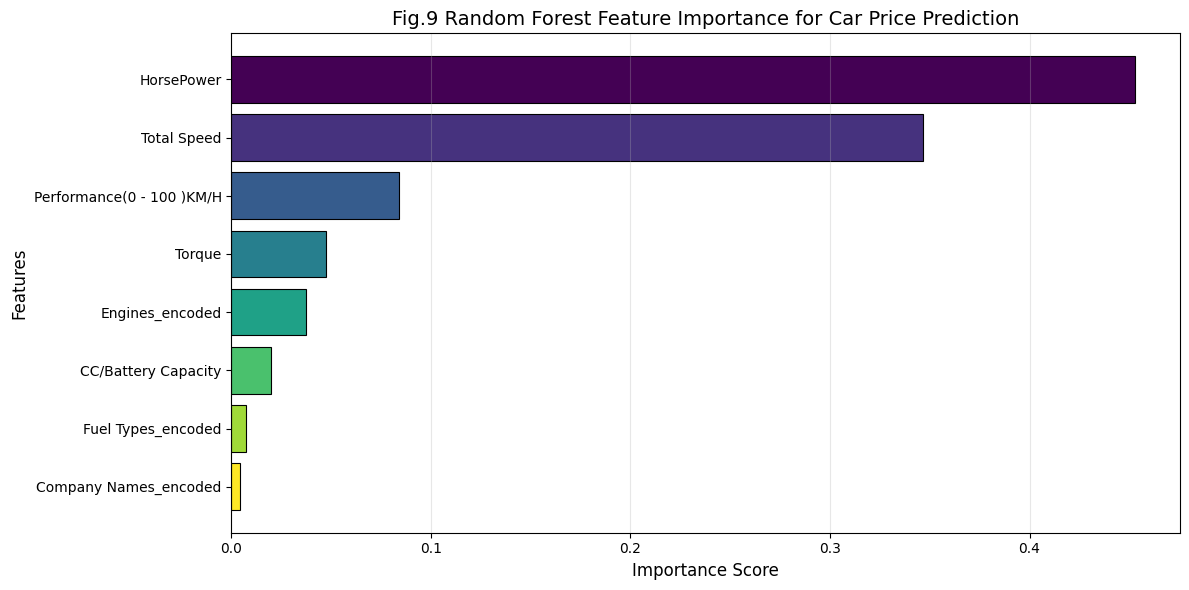

In [30]:
# Feature Importance from Random Forest Model
feature_importance = rf_pipeline.named_steps['rf_regressor'].feature_importances_
feature_names = features

# Create a DataFrame for better visualization
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importance
}).sort_values(by='Importance', ascending=False)

# Plot Feature Importance
plt.figure(figsize=(12, 6))
colors = plt.cm.viridis(np.linspace(0, 1, len(importance_df)))
bars = plt.barh(importance_df['Feature'], importance_df['Importance'], color=colors, edgecolor='black', linewidth=0.8)
plt.xlabel('Importance Score', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.title('Fig.9 Random Forest Feature Importance for Car Price Prediction', fontsize=14)
plt.gca().invert_yaxis()
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

## Conclusion

This comprehensive analysis of 1000+ vehicles from the 2025 Cars Dataset successfully developed and evaluated machine learning models for car price prediction. The study reveals critical insights into the automotive market's pricing dynamics and the relationship between technical specifications and vehicle value.

This analysis demonstrates that machine learning, particularly Random Forest Regression, can predict car prices with substantially better accuracy than a linear baseline. The R² score improves from 0.51 (Linear Regression) to 0.77 (Random Forest), indicating stronger explanatory power when non-linear patterns are modeled. The model improved performance substantially over Linear Regression (MAE: USD 196,655.68 to USD 43,335.41; R²: 0.51 to 0.77). However, RMSE of USD 293,773.92 indicates that very high-end vehicle pricing remains difficult to model, likely due to:
- Brand heritage and prestige factors not captured in technical specifications
- Limited edition models and collector value considerations
- Market positioning strategies beyond measurable performance metrics

The systematic workflow from data cleaning and preprocessing through exploratory analysis to model development provides a robust framework for automotive price prediction. At the same time, the remaining RMSE (USD 293,773.92) suggests that additional non-technical factors such as brand prestige, exclusivity, and market positioning still influence price beyond the current feature set.

### Key Findings

**1. Model Performance**
- Random Forest Regression outperformed Linear Regression with R² = 0.77 compared to 0.51
- The Random Forest model reduced MAE from USD 196,655.68 to USD 43,335.41 (about 78% reduction)
- RMSE improved to USD 293,773.92, though extreme luxury prices remain challenging

**2. Price Distribution Insights**
- Highly right-skewed distribution with extreme skewness and kurtosis
- Median price remains far below mean price, indicating strong luxury outlier influence
- Wide price range spans economy to hypercar segments

**3. Feature Correlations**
- HorsePower shows one of the strongest positive relationships with car price among technical variables
- Performance (0-100 KM/H) is negatively correlated with HorsePower and Total Speed
- Modest-to-strong correlations suggest both technical features and brand effects influence pricing

**4. Brand Positioning**
- Luxury brands (Bugatti, Ferrari, Lamborghini, Rolls-Royce) command premium prices with significant outliers
- Mass-market manufacturers (Suzuki, Honda, Toyota) remain concentrated in lower price bands
- Premium brands (BMW, Mercedes, Audi) occupy intermediate ranges with moderate variability

**5. Fuel Type Economics**
- Hybrid/petrol combinations tend to appear in higher-priced segments
- Alternative fuels such as Hydrogen and Gas are often associated with higher-end models
- Electric and CNG vehicles remain among more accessible options in this dataset

## Recommendations

#### For Consumers

1. Value Assessment: Technical specifications are important, but market positioning and brand prestige also influence price
2. Performance vs. Price: HorsePower remains a major driver; compare performance gains against real price premium
3. Fuel Type Considerations: Electric and CNG vehicles generally remain more affordable entry points

#### For Automotive Industry

1. Pricing Strategy: With an R² score of 0.77, technical and categorical features explain much of price behavior, but premium pricing still reflects brand equity and segment strategy
2. Market Segmentation: Clear stratification exists between economy, mainstream, premium, and luxury segments
3. Performance Tiers: Strong HorsePower and Total Speed relationships suggest consistent engineering tiers across segments

#### For Future Analysis

1. Feature Enhancement: Add brand heritage scores, safety ratings, technology features, and market positioning indicators
2. Segment-Specific Models: Build separate models for economy, mainstream, premium, and luxury classes
3. Temporal Analysis: Include model year, depreciation, and demand trends
4. Advanced Techniques: Evaluate gradient boosting and stacked ensembles for further RMSE reduction
5. External Factors: Integrate economic indicators, fuel prices, and regional preference patterns